## 1. Setup and Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure display and plotting
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set figure size defaults
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Mouza_Census_FinalReduced.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nDistricts: {df.shape[0]}")
print(f"Features: {df.shape[1]}")
print(f"\nProvinces: {df['Name of Province'].nunique()}")
print(f"Divisions: {df['Name of Division'].nunique()}")

Dataset Shape: (151, 123)

Districts: 151
Features: 123

Provinces: 7
Divisions: 37


## 2. Initial Data Exploration

In [3]:
# Display first few rows
df.head()

,Name of District,Name of Province,Name of Division,Total Tehsils,Total Number of Settlements,Total Villages,Ratio of mouzas with Pucca houses,Ratio of mouzas with Kutcha houses,Ratio of mouzas with Pucca/Kutcha houses,Ratio of mouzas with Other houses,Ratio of mouzas having complete electricity supply,Ratio of mouzas having mostly electricity supply,Ratio of mouzas having some electricity supply,Ratio of mouzas having no electricity supply,Average Distance to Electricity in case of unavailability (in km),Ratio of mouzas having Solar as alternate electricity source,Ratio of mouzas having Bio Gas as alternate electricity source,Ratio of mouzas having Generator as alternate electricity source,Ratio of mouzas having Others as alternate electricity source,Ratio of mouzas having no alternate electricity source,Ratio of mouzas having Sui Gas (Natural Gas) as fuel,Ratio of mouzas having LPG as fuel,Ratio of mouzas having Kerosene Oil as fuel,Ratio of mouzas having Wood as fuel,Ratio of mouzas having Coal as fuel,Ratio of mouzas with sweet underground water,Average Distance to Sweet Water in case of unavailability (in km),Average Depth of Water Table (ft),Ratio of mouzas with govt piped supply for drinking water,Ratio of mouzas with personal hand/electric pump for drinking water,Ratio of mouzas with water filtration plant for drinking water,Ratio of mouzas with reverse osmosis plant for drinking water,Ratio of mouzas with pump on canal for drinking water,Ratio of mouzas with well for drinking water,Ratio of mouzas with river/canal for drinking water,Ratio of mouzas with spring/karez for drinking water,Ratio of mouzas with pond/toba for drinking water,Ratio of mouzas with other sources for drinking water,Ratio of mouzas with outside toilet facility,Ratio of mouzas with inside toilet facility,Ratio of mouzas having CNG/LPG Facility,Average Distance to CNG/LPG Facility in case of unavailability (in km),Ratio of mouzas having Fuel Pump,Average Distance to Fuel Pump in case of unavailability (in km),Ratio of mouzas with Metalled Streets,Ratio of mouzas with Cemented Streets,Ratio of mouzas with Bricked Streets,Ratio of mouzas with Unmetalled Streets,Mode - Road Type leading upto mouzas,Average Distance of Unmetalled Road leading up to mouza (km),Ratio of mouzas with no waste management,Ratio of mouzas with any waste management,Ratio of mouzas with government waste management,Ratio of mouzas with private waste management,Ratio of mouzas with all cemented drains,Ratio of mouzas with mostly cemented drains,Ratio of mouzas with some cemented drains,Ratio of mouzas with no cemented drains,Ratio of mouzas with complete sewerage system coverage,Ratio of mouzas with mostly sewerage system coverage,Ratio of mouzas with some sewerage system coverage,Ratio of mouzas with no sewerage system coverage,Ratio of mouzas having Radio as media source,Ratio of mouzas having TV as media source,Ratio of mouzas having Cable as media source,Ratio of mouzas having Newspaper as media source,Ratio of mouzas having No media sources,Ratio of mouzas having PCO,Average Distance to PCO in case of unavailability (in km),Ratio of mouzas having Mobile Signals,Average Distance to Mobile Signals in case of unavailability (in km),Ratio of mouzas with fixed line DSL,Average Distance to Fixed Line DSL in case of unavailability (in km),Ratio of mouzas with cable net,Average Distance to Cable Net in case of unavailability (in km),Ratio of mouzas with mobile net,Average Distance to Mobile Net in case of unavailability (in km),Ratio of mouzas having Transport Facility,Average Distance to Transport Facility in case of unavailability (in km),Ratio of mouzas having Market,Average Distance to Market in case of unavailability (in km),Ratio of mouzas having grains market,Average Distance to Grains Market in case of unavailability (in km),Ratio of mouzas having fruits/vegetables market,Average Distance to Fruits/Vegetables Market in case of unavailability (in km),Ratio of mouzas having Col

In [4]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Columns: 123 entries, Name of District to Ratio of mouzas having Mobile Veterinary Dispenser
dtypes: float64(116), int64(3), object(4)
memory usage: 145.2+ KB


In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
}).sort_values('Missing_Percentage', ascending=False)

print("Columns with Missing Values:")
print(missing_df[missing_df['Missing_Count'] > 0].head(20))

Columns with Missing Values:
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []


In [6]:
# Geographic distribution
print("Districts by Province:")
print(df['Name of Province'].value_counts())
print("\n" + "="*60 + "\n")
print("Top 10 Divisions by District Count:")
print(df['Name of Division'].value_counts().head(10))

Districts by Province:
Name of Province
PUNJAB                         37
KHYBER PAKHTUNKHWA             35
BALOCHISTAN                    33
SINDH                          25
GILGIT BALTISTAN               10
AZAD JAMMU AND KASHMIR         10
ISLAMABAD CAPITAL TERRITORY     1
Name: count, dtype: int64


Top 10 Divisions by District Count:
Name of Division
MALAKAND DIVISION      9
HYDERABAD DIVISION     9
HAZARA DIVISION        8
ZHOB DIVISION          7
KALAT DIVISION         6
GUJRANWALA DIVISION    6
LARKANA DIVISION       5
KOHAT DIVISION         5
PESHAWAR DIVISION      5
SIBI DIVISION          5
Name: count, dtype: int64


## 3. Housing Infrastructure Analysis

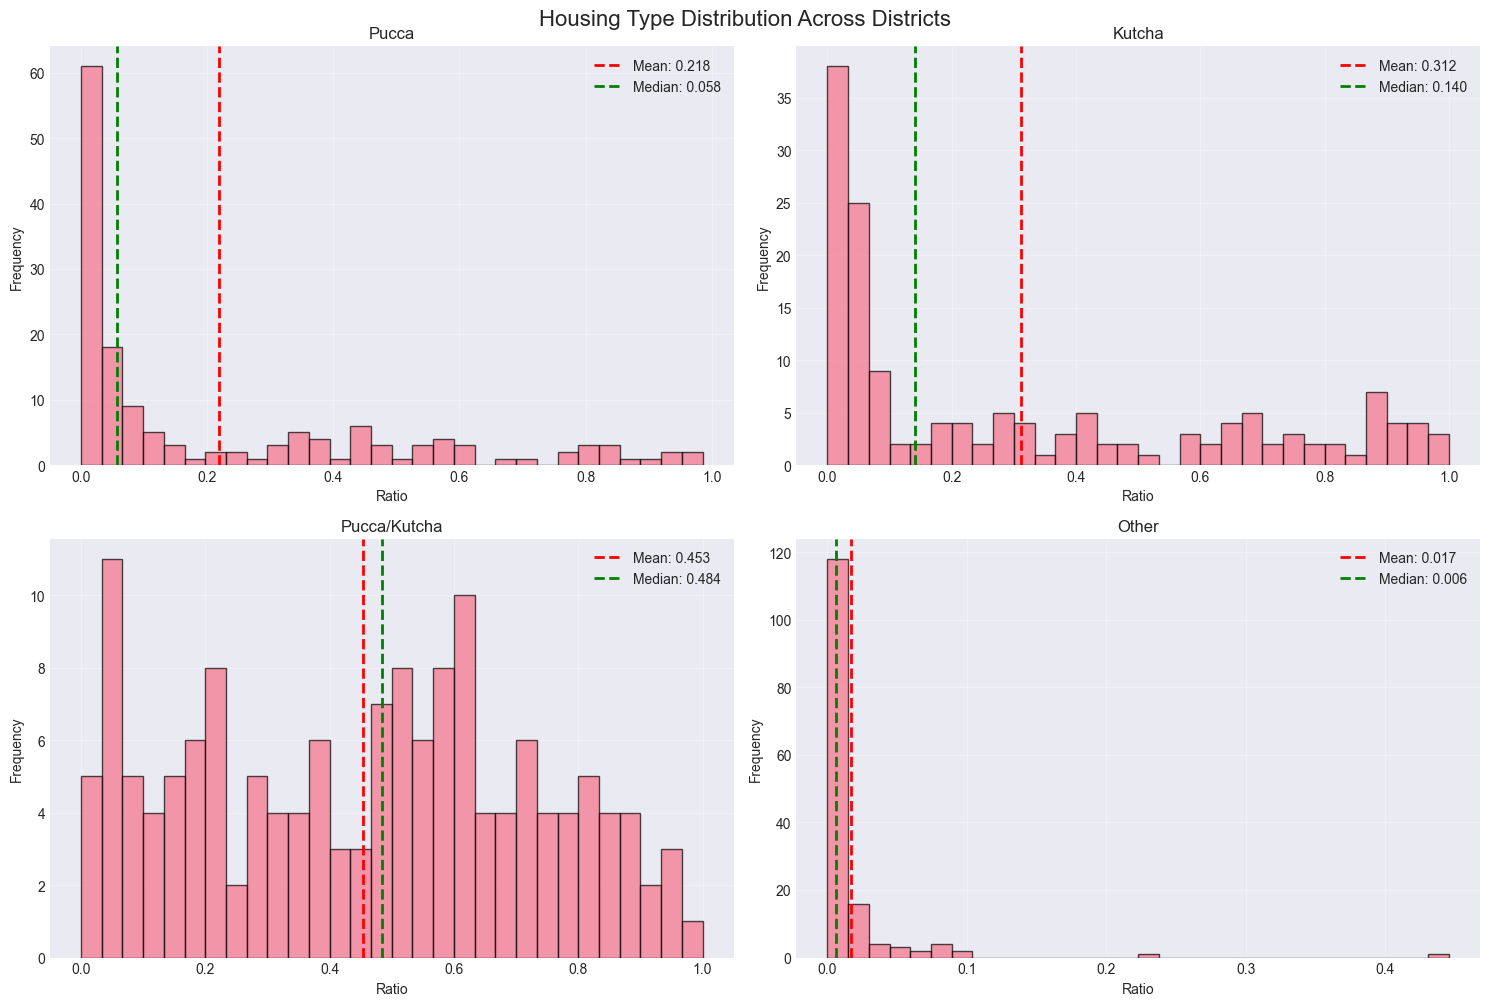


Housing Statistics:
       Ratio of mouzas with Pucca houses  Ratio of mouzas with Kutcha houses  \
count                         151.000000                          151.000000   
mean                            0.218307                            0.311658   
std                             0.279944                            0.331960   
min                             0.000000                            0.000000   
25%                             0.013699                            0.032399   
50%                             0.057789                            0.140244   
75%                             0.387161                            0.601802   
max                             0.985401                            1.000000   

       Ratio of mouzas with Pucca/Kutcha houses  \
count                                151.000000   
mean                                   0.453431   
std                                    0.273232   
min                                    0.000000   
25%

In [7]:
# Housing type distribution
housing_cols = ['Ratio of mouzas with Pucca houses', 
                'Ratio of mouzas with Kutcha houses',
                'Ratio of mouzas with Pucca/Kutcha houses',
                'Ratio of mouzas with Other houses']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(housing_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.3f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.3f}')
    axes[idx].set_xlabel('Ratio')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(col.replace('Ratio of mouzas with ', '').replace(' houses', ''))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Housing Type Distribution Across Districts', fontsize=16, y=1.002)
plt.show()

print("\nHousing Statistics:")
print(df[housing_cols].describe())

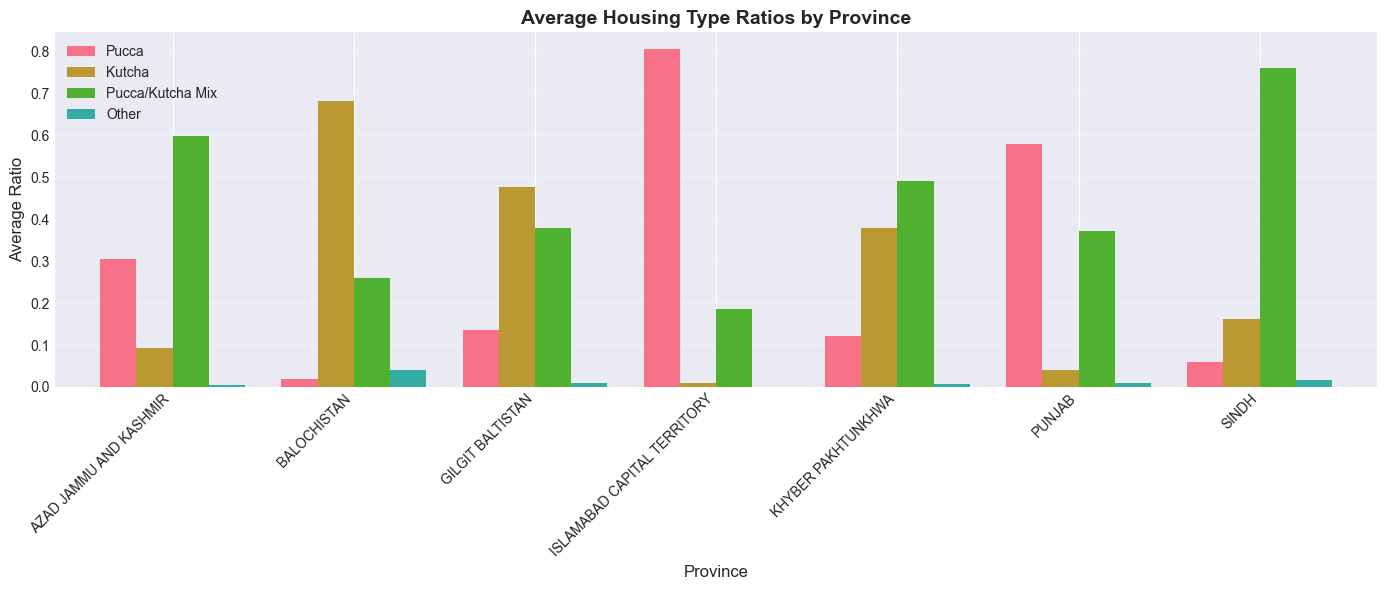

                             Ratio of mouzas with Pucca houses  \
Name of Province                                                 
AZAD JAMMU AND KASHMIR                                0.305186   
BALOCHISTAN                                           0.019293   
GILGIT BALTISTAN                                      0.135366   
ISLAMABAD CAPITAL TERRITORY                           0.805556   
KHYBER PAKHTUNKHWA                                    0.120440   
PUNJAB                                                0.578791   
SINDH                                                 0.059438   

                             Ratio of mouzas with Kutcha houses  \
Name of Province                                                  
AZAD JAMMU AND KASHMIR                                 0.093175   
BALOCHISTAN                                            0.681252   
GILGIT BALTISTAN                                       0.476205   
ISLAMABAD CAPITAL TERRITORY                            0.009259   
KHY

In [8]:
# Housing by Province
housing_by_province = df.groupby('Name of Province')[housing_cols].mean()

housing_by_province.plot(kind='bar', figsize=(14, 6), width=0.8)
plt.title('Average Housing Type Ratios by Province', fontsize=14, fontweight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Average Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(labels=['Pucca', 'Kutcha', 'Pucca/Kutcha Mix', 'Other'], loc='best')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(housing_by_province)

## 4. Electricity Access Analysis

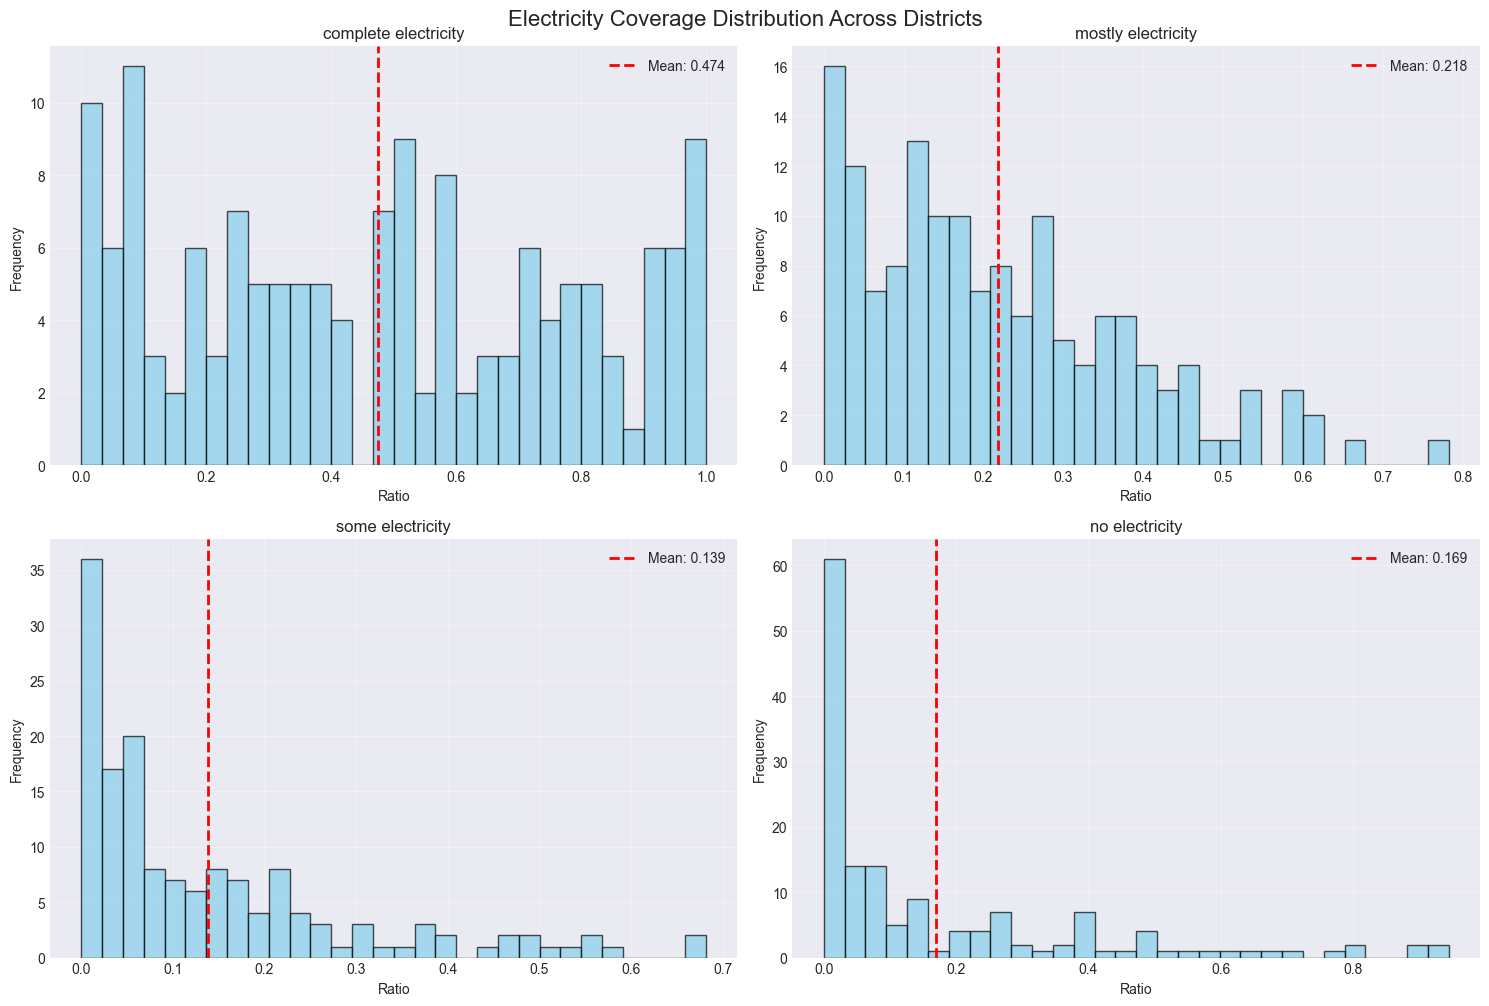


Electricity Statistics:
       Ratio of mouzas having complete electricity supply  \
count                                         151.000000    
mean                                            0.474492    
std                                             0.313178    
min                                             0.000000    
25%                                             0.199603    
50%                                             0.487119    
75%                                             0.744180    
max                                             1.000000    

       Ratio of mouzas having mostly electricity supply  \
count                                        151.000000   
mean                                           0.217727   
std                                            0.166451   
min                                            0.000000   
25%                                            0.089295   
50%                                            0.181373   
75%         

In [9]:
# Electricity availability patterns
elec_cols = ['Ratio of mouzas having complete electricity supply',
             'Ratio of mouzas having mostly electricity supply',
             'Ratio of mouzas having some electricity supply',
             'Ratio of mouzas having no electricity supply']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(elec_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.3f}')
    axes[idx].set_xlabel('Ratio')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(col.replace('Ratio of mouzas having ', '').replace(' supply', ''))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Electricity Coverage Distribution Across Districts', fontsize=16, y=1.002)
plt.show()

print("\nElectricity Statistics:")
print(df[elec_cols].describe())

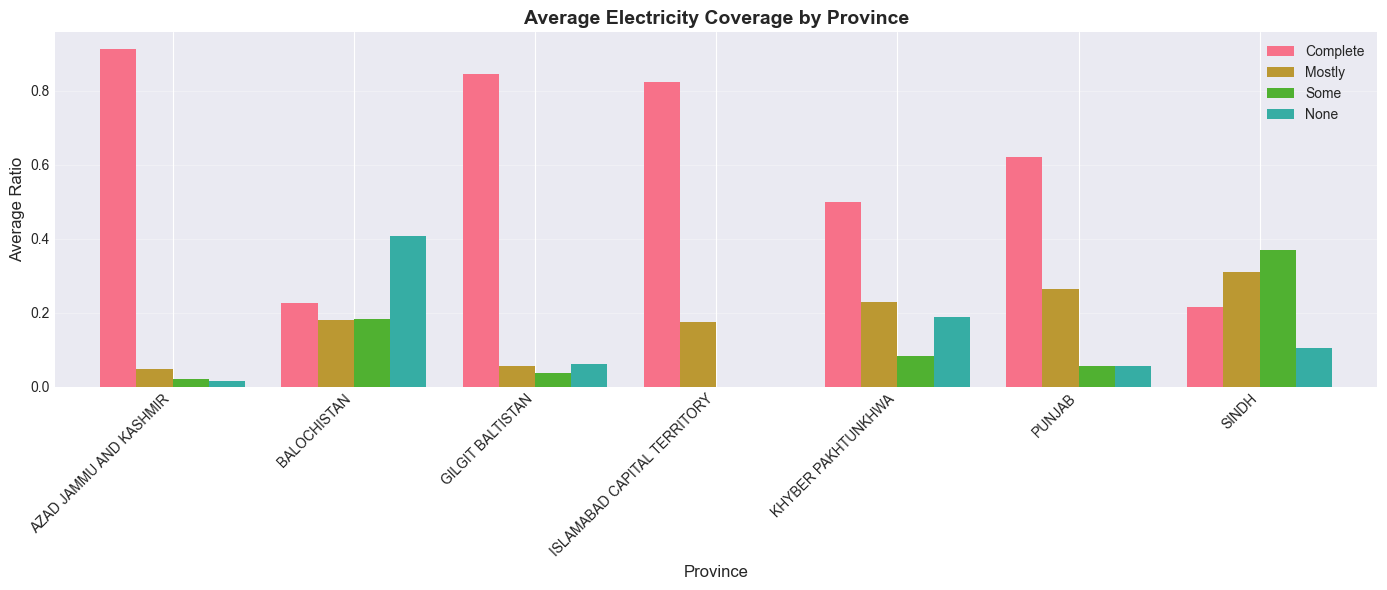

                             Ratio of mouzas having complete electricity supply  \
Name of Province                                                                  
AZAD JAMMU AND KASHMIR                                                0.911878    
BALOCHISTAN                                                           0.226123    
GILGIT BALTISTAN                                                      0.843718    
ISLAMABAD CAPITAL TERRITORY                                           0.824074    
KHYBER PAKHTUNKHWA                                                    0.498578    
PUNJAB                                                                0.621045    
SINDH                                                                 0.215090    

                             Ratio of mouzas having mostly electricity supply  \
Name of Province                                                                
AZAD JAMMU AND KASHMIR                                               0.049275   
BALOCHIST

In [10]:
# Electricity by Province
elec_by_province = df.groupby('Name of Province')[elec_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
elec_by_province.plot(kind='bar', ax=ax, width=0.8)
plt.title('Average Electricity Coverage by Province', fontsize=14, fontweight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Average Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(labels=['Complete', 'Mostly', 'Some', 'None'], loc='best')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(elec_by_province)

In [11]:
# Top 10 districts with best electricity coverage
df['Total_Electricity_Access'] = (df['Ratio of mouzas having complete electricity supply'] + 
                                   df['Ratio of mouzas having mostly electricity supply'])

top_elec = df.nlargest(10, 'Total_Electricity_Access')[['Name of District', 'Name of Province', 'Total_Electricity_Access']]
print("\nTop 10 Districts with Best Electricity Access:")
print(top_elec)

# Bottom 10 districts
bottom_elec = df.nsmallest(10, 'Total_Electricity_Access')[['Name of District', 'Name of Province', 'Total_Electricity_Access']]
print("\nBottom 10 Districts with Worst Electricity Access:")
print(bottom_elec)


Top 10 Districts with Best Electricity Access:
            Name of District             Name of Province  \
16   MALAKAND PROTECTED AREA           KHYBER PAKHTUNKHWA   
122       ISLAMABAD DISTRICT  ISLAMABAD CAPITAL TERRITORY   
130        KHARMANG DISTRICT             GILGIT BALTISTAN   
140          POONCH DISTRICT       AZAD JAMMU AND KASHMIR   
141        SUDHNOTI DISTRICT       AZAD JAMMU AND KASHMIR   
133           KOTLI DISTRICT       AZAD JAMMU AND KASHMIR   
37       GUJRANWALA DISTRICT                       PUNJAB   
4        ABBOTTABAD DISTRICT           KHYBER PAKHTUNKHWA   
34       FAISALABAD DISTRICT                       PUNJAB   
132         BHIMBER DISTRICT       AZAD JAMMU AND KASHMIR   

     Total_Electricity_Access  
16                   1.000000  
122                  1.000000  
130                  1.000000  
140                  1.000000  
141                  1.000000  
133                  1.000000  
37                   0.997540  
4                    0.9

## 5. Water Access Analysis

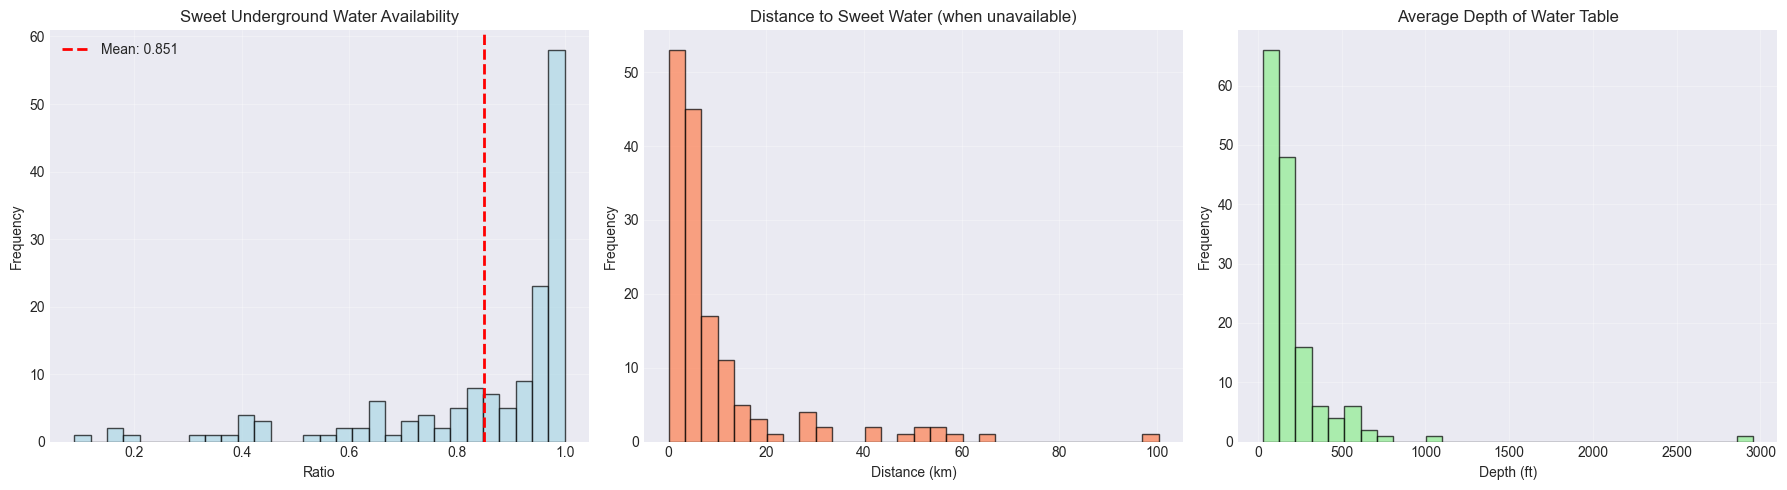


Water Statistics:
       Ratio of mouzas with sweet underground water  \
count                                    151.000000   
mean                                       0.851043   
std                                        0.205196   
min                                        0.089655   
25%                                        0.806640   
50%                                        0.952663   
75%                                        0.987404   
max                                        1.000000   

       Average Distance to Sweet Water in case of unavailability (in km)  \
count                                         151.000000                   
mean                                            9.676003                   
std                                            14.713026                   
min                                             0.000000                   
25%                                             2.810093                   
50%                          

In [12]:
# Sweet water availability
water_cols = ['Ratio of mouzas with sweet underground water',
              'Average Distance to Sweet Water in case of unavailability (in km)',
              'Average Depth of Water Table (ft)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sweet water ratio
axes[0].hist(df['Ratio of mouzas with sweet underground water'], bins=30, edgecolor='black', alpha=0.7, color='lightblue')
axes[0].axvline(df['Ratio of mouzas with sweet underground water'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Mean: {df['Ratio of mouzas with sweet underground water'].mean():.3f}")
axes[0].set_xlabel('Ratio')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sweet Underground Water Availability')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distance to sweet water
axes[1].hist(df['Average Distance to Sweet Water in case of unavailability (in km)'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distance to Sweet Water (when unavailable)')
axes[1].grid(True, alpha=0.3)

# Water table depth
axes[2].hist(df['Average Depth of Water Table (ft)'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].set_xlabel('Depth (ft)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Average Depth of Water Table')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWater Statistics:")
print(df[water_cols].describe())

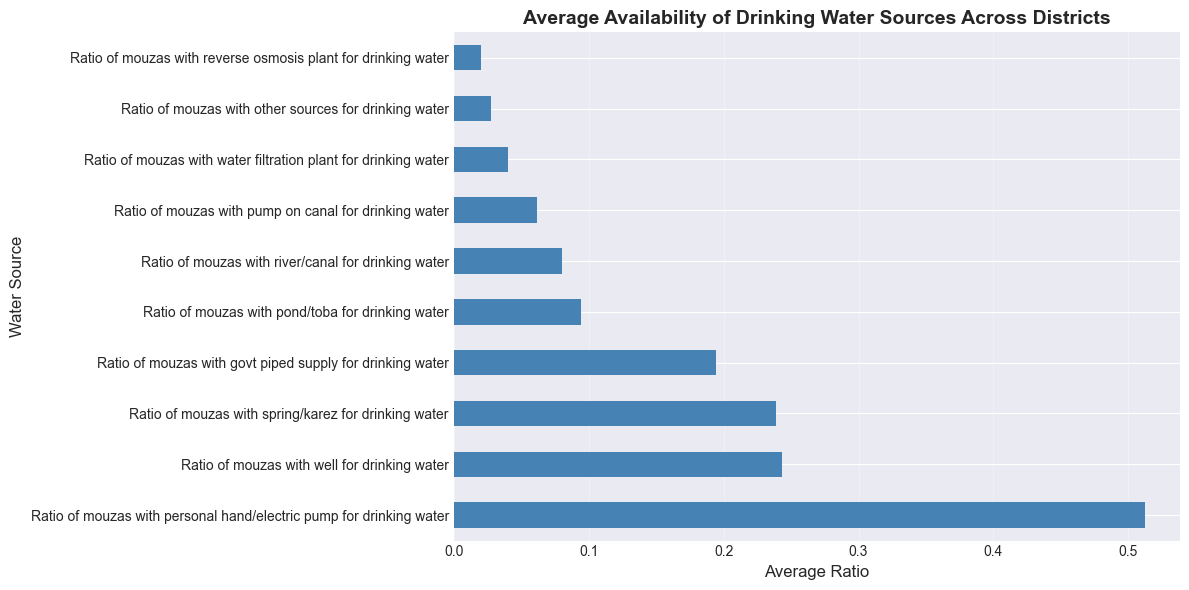


Drinking Water Sources (sorted by availability):
Ratio of mouzas with personal hand/electric pump for drinking water    0.512567
Ratio of mouzas with well for drinking water                           0.243215
Ratio of mouzas with spring/karez for drinking water                   0.239115
Ratio of mouzas with govt piped supply for drinking water              0.194066
Ratio of mouzas with pond/toba for drinking water                      0.094592
Ratio of mouzas with river/canal for drinking water                    0.080511
Ratio of mouzas with pump on canal for drinking water                  0.061391
Ratio of mouzas with water filtration plant for drinking water         0.040489
Ratio of mouzas with other sources for drinking water                  0.027754
Ratio of mouzas with reverse osmosis plant for drinking water          0.020318
dtype: float64


In [13]:
# Drinking water sources
drinking_water_cols = [col for col in df.columns if 'drinking water' in col.lower()]

avg_sources = df[drinking_water_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_sources.plot(kind='barh', color='steelblue')
plt.title('Average Availability of Drinking Water Sources Across Districts', fontsize=14, fontweight='bold')
plt.xlabel('Average Ratio', fontsize=12)
plt.ylabel('Water Source', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDrinking Water Sources (sorted by availability):")
print(avg_sources)

## 6. Sanitation and Waste Management

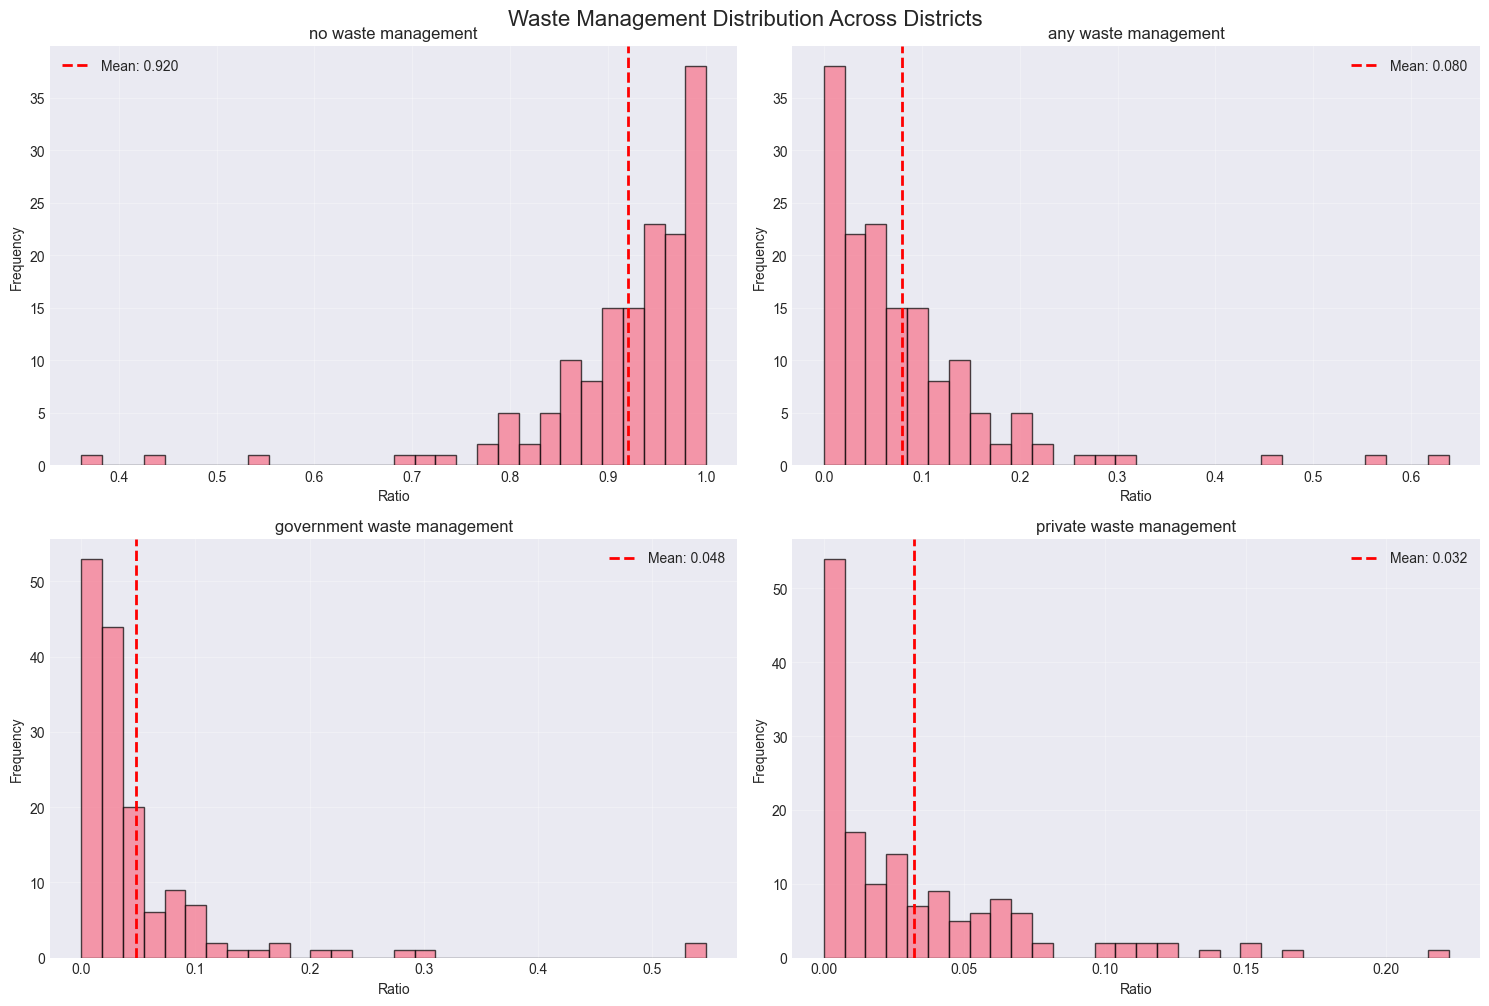


Waste Management Statistics:
       Ratio of mouzas with no waste management  \
count                                151.000000   
mean                                   0.920350   
std                                    0.092907   
min                                    0.361823   
25%                                    0.893815   
50%                                    0.950000   
75%                                    0.978110   
max                                    1.000000   

       Ratio of mouzas with any waste management  \
count                                 151.000000   
mean                                    0.079650   
std                                     0.092907   
min                                     0.000000   
25%                                     0.021890   
50%                                     0.050000   
75%                                     0.106185   
max                                     0.638177   

       Ratio of mouzas with government wa

In [14]:
# Waste management and sanitation
sanit_cols = ['Ratio of mouzas with no waste management',
              'Ratio of mouzas with any waste management',
              'Ratio of mouzas with government waste management',
              'Ratio of mouzas with private waste management']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(sanit_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.3f}')
    axes[idx].set_xlabel('Ratio')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(col.replace('Ratio of mouzas with ', ''))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Waste Management Distribution Across Districts', fontsize=16, y=1.002)
plt.show()

print("\nWaste Management Statistics:")
print(df[sanit_cols].describe())

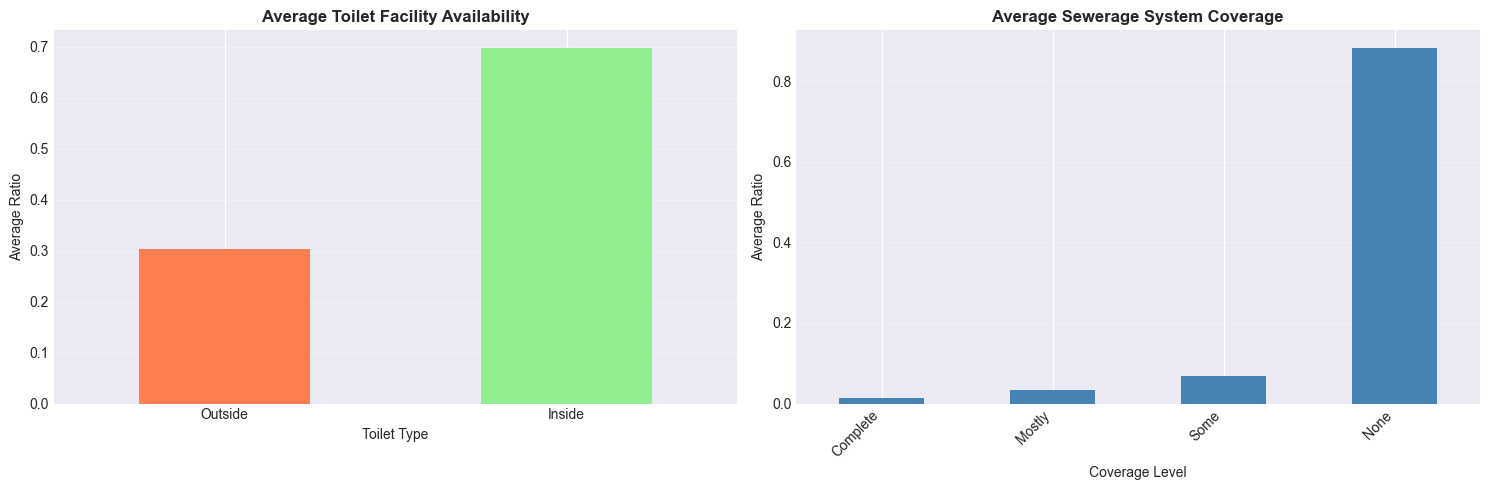


Sanitation Facilities Statistics:
       Ratio of mouzas with outside toilet facility  \
count                                    151.000000   
mean                                       0.302891   
std                                        0.309263   
min                                        0.000000   
25%                                        0.044406   
50%                                        0.156250   
75%                                        0.529623   
max                                        1.000000   

       Ratio of mouzas with inside toilet facility  \
count                                   151.000000   
mean                                      0.697109   
std                                       0.309263   
min                                       0.000000   
25%                                       0.470377   
50%                                       0.843750   
75%                                       0.955594   
max                                  

In [15]:
# Toilet facilities and sewerage
toilet_cols = ['Ratio of mouzas with outside toilet facility',
               'Ratio of mouzas with inside toilet facility']

sewerage_cols = ['Ratio of mouzas with complete sewerage system coverage',
                 'Ratio of mouzas with mostly sewerage system coverage',
                 'Ratio of mouzas with some sewerage system coverage',
                 'Ratio of mouzas with no sewerage system coverage']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Toilet facilities
df[toilet_cols].mean().plot(kind='bar', ax=axes[0], color=['coral', 'lightgreen'])
axes[0].set_title('Average Toilet Facility Availability', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Toilet Type')
axes[0].set_ylabel('Average Ratio')
axes[0].set_xticklabels(['Outside', 'Inside'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Sewerage system
df[sewerage_cols].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average Sewerage System Coverage', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coverage Level')
axes[1].set_ylabel('Average Ratio')
axes[1].set_xticklabels(['Complete', 'Mostly', 'Some', 'None'], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSanitation Facilities Statistics:")
print(df[toilet_cols + sewerage_cols].describe())

## 7. Connectivity Analysis

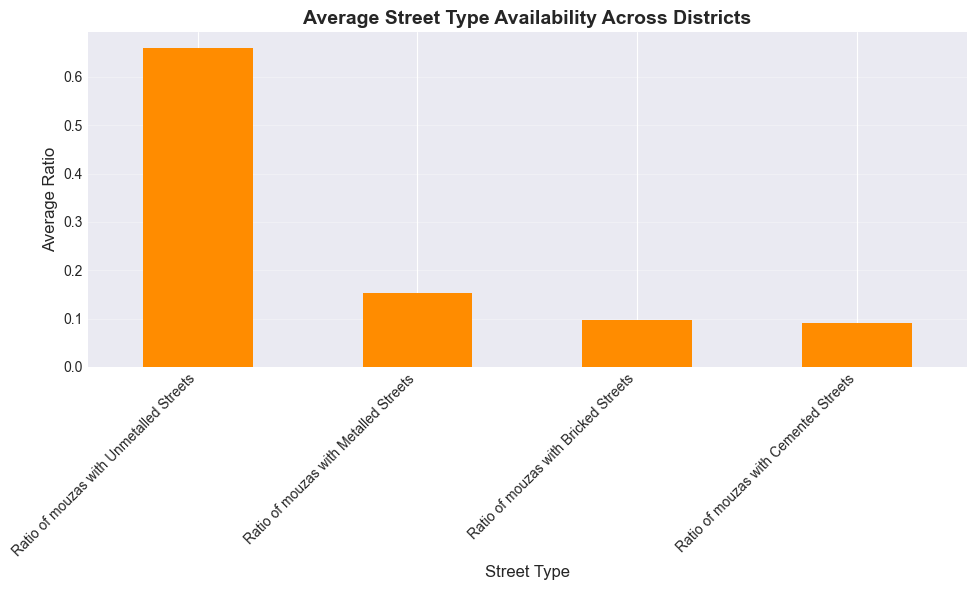


Street Types Statistics:
       Ratio of mouzas with Metalled Streets  \
count                             151.000000   
mean                                0.153630   
std                                 0.158452   
min                                 0.000000   
25%                                 0.033295   
50%                                 0.107143   
75%                                 0.210084   
max                                 0.785294   

       Ratio of mouzas with Cemented Streets  \
count                             151.000000   
mean                                0.090856   
std                                 0.139624   
min                                 0.000000   
25%                                 0.007929   
50%                                 0.021374   
75%                                 0.101515   
max                                 0.764706   

       Ratio of mouzas with Bricked Streets  \
count                            151.000000   
mean          

In [16]:
# Road and street infrastructure
street_cols = ['Ratio of mouzas with Metalled Streets',
               'Ratio of mouzas with Cemented Streets',
               'Ratio of mouzas with Bricked Streets',
               'Ratio of mouzas with Unmetalled Streets']

avg_streets = df[street_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_streets.plot(kind='bar', color='darkorange')
plt.title('Average Street Type Availability Across Districts', fontsize=14, fontweight='bold')
plt.xlabel('Street Type', fontsize=12)
plt.ylabel('Average Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nStreet Types Statistics:")
print(df[street_cols].describe())

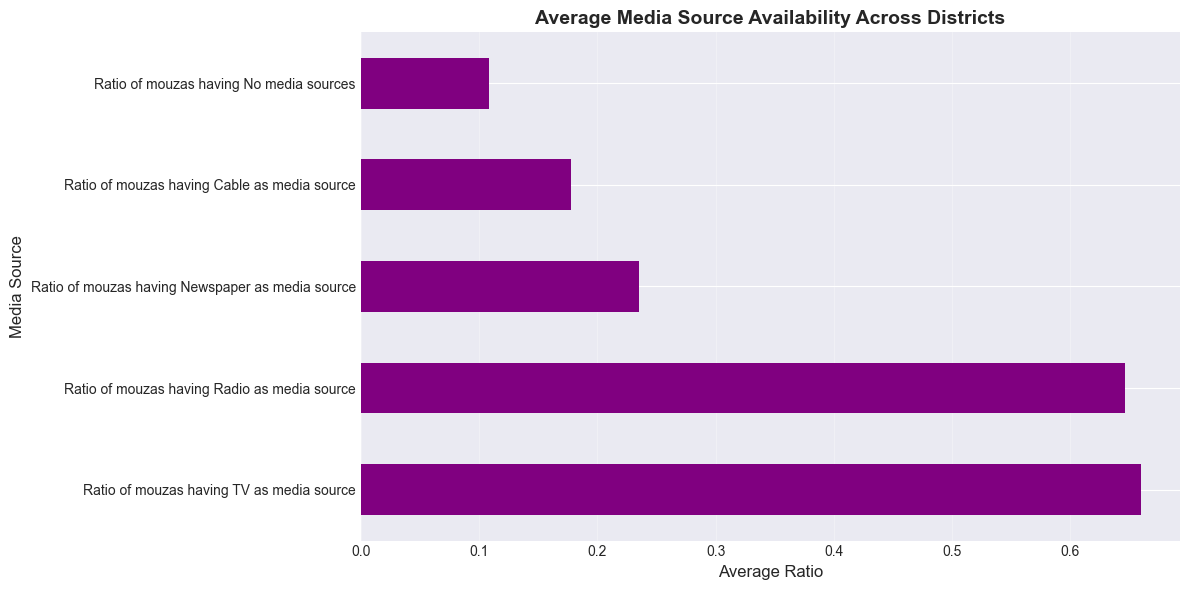


Media Sources Statistics:
       Ratio of mouzas having Radio as media source  \
count                                    151.000000   
mean                                       0.646147   
std                                        0.198188   
min                                        0.149701   
25%                                        0.506706   
50%                                        0.634483   
75%                                        0.814050   
max                                        1.000000   

       Ratio of mouzas having TV as media source  \
count                                 151.000000   
mean                                    0.659608   
std                                     0.313254   
min                                     0.000000   
25%                                     0.395999   
50%                                     0.776119   
75%                                     0.932786   
max                                     1.000000   

       R

In [17]:
# Communication and media
media_cols = ['Ratio of mouzas having Radio as media source',
              'Ratio of mouzas having TV as media source',
              'Ratio of mouzas having Cable as media source',
              'Ratio of mouzas having Newspaper as media source',
              'Ratio of mouzas having No media sources']

avg_media = df[media_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_media.plot(kind='barh', color='purple')
plt.title('Average Media Source Availability Across Districts', fontsize=14, fontweight='bold')
plt.xlabel('Average Ratio', fontsize=12)
plt.ylabel('Media Source', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMedia Sources Statistics:")
print(df[media_cols].describe())

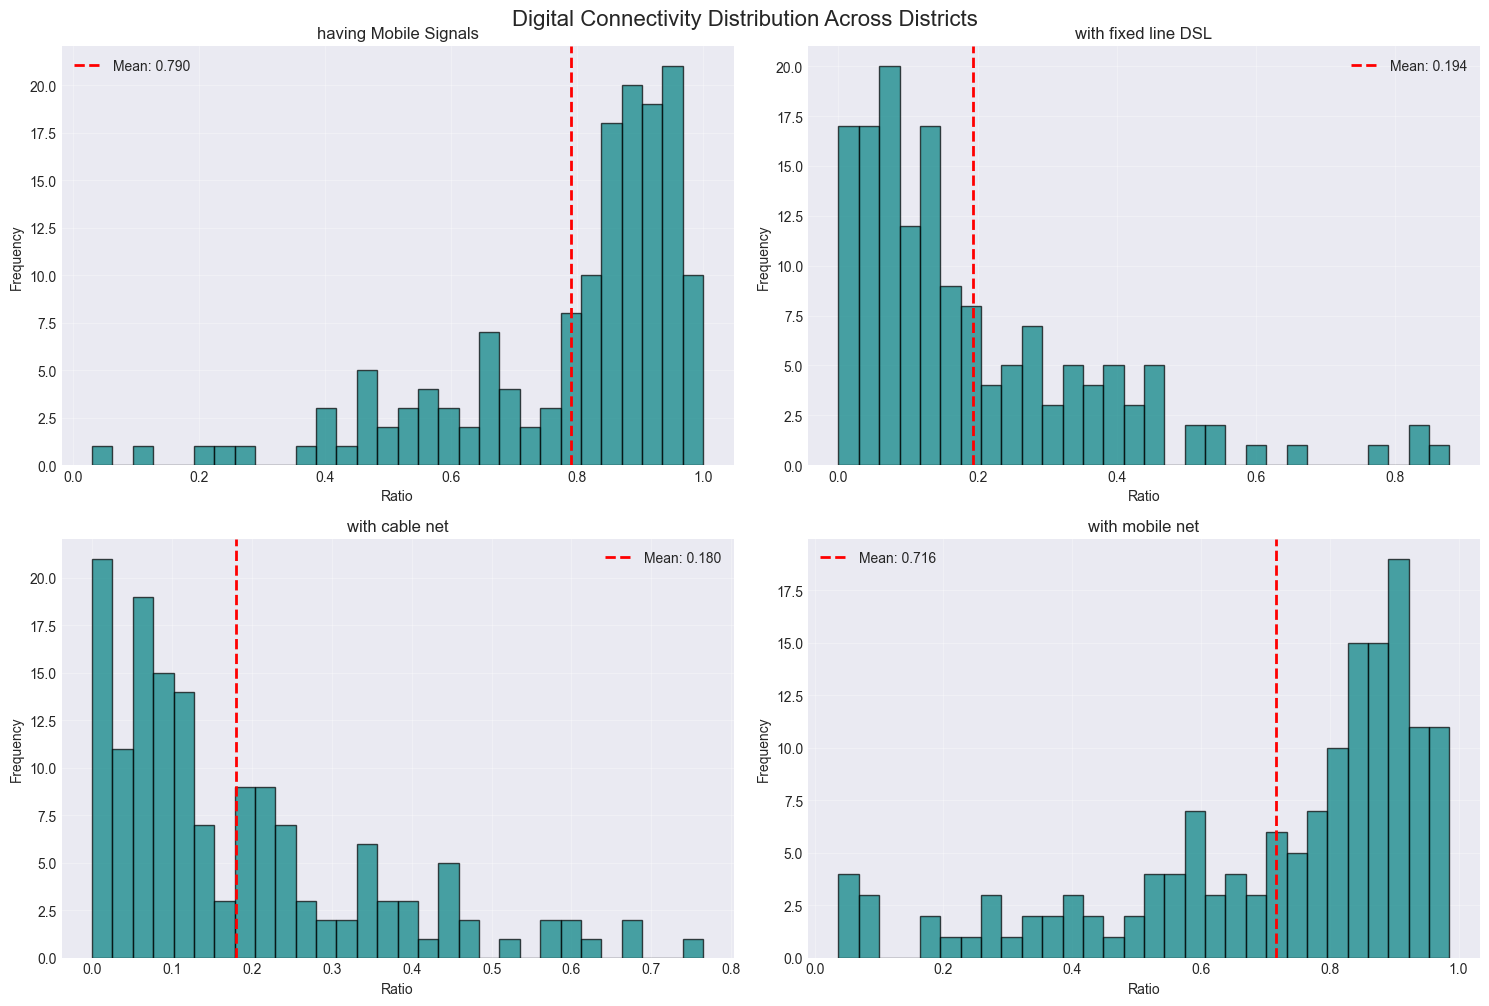


Connectivity Statistics:
       Ratio of mouzas having Mobile Signals  \
count                             151.000000   
mean                                0.790000   
std                                 0.193718   
min                                 0.030303   
25%                                 0.698851   
50%                                 0.859688   
75%                                 0.928646   
max                                 1.000000   

       Ratio of mouzas with fixed line DSL  Ratio of mouzas with cable net  \
count                           151.000000                      151.000000   
mean                              0.194000                        0.180412   
std                               0.180416                        0.165966   
min                               0.000000                        0.000000   
25%                               0.068053                        0.061167   
50%                               0.137405                        0.12288

In [18]:
# Internet and mobile connectivity
connect_cols = ['Ratio of mouzas having Mobile Signals',
                'Ratio of mouzas with fixed line DSL',
                'Ratio of mouzas with cable net',
                'Ratio of mouzas with mobile net']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(connect_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='teal')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.3f}')
    axes[idx].set_xlabel('Ratio')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(col.replace('Ratio of mouzas ', ''))
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Digital Connectivity Distribution Across Districts', fontsize=16, y=1.002)
plt.show()

print("\nConnectivity Statistics:")
print(df[connect_cols].describe())

## 8. Health Facilities Analysis

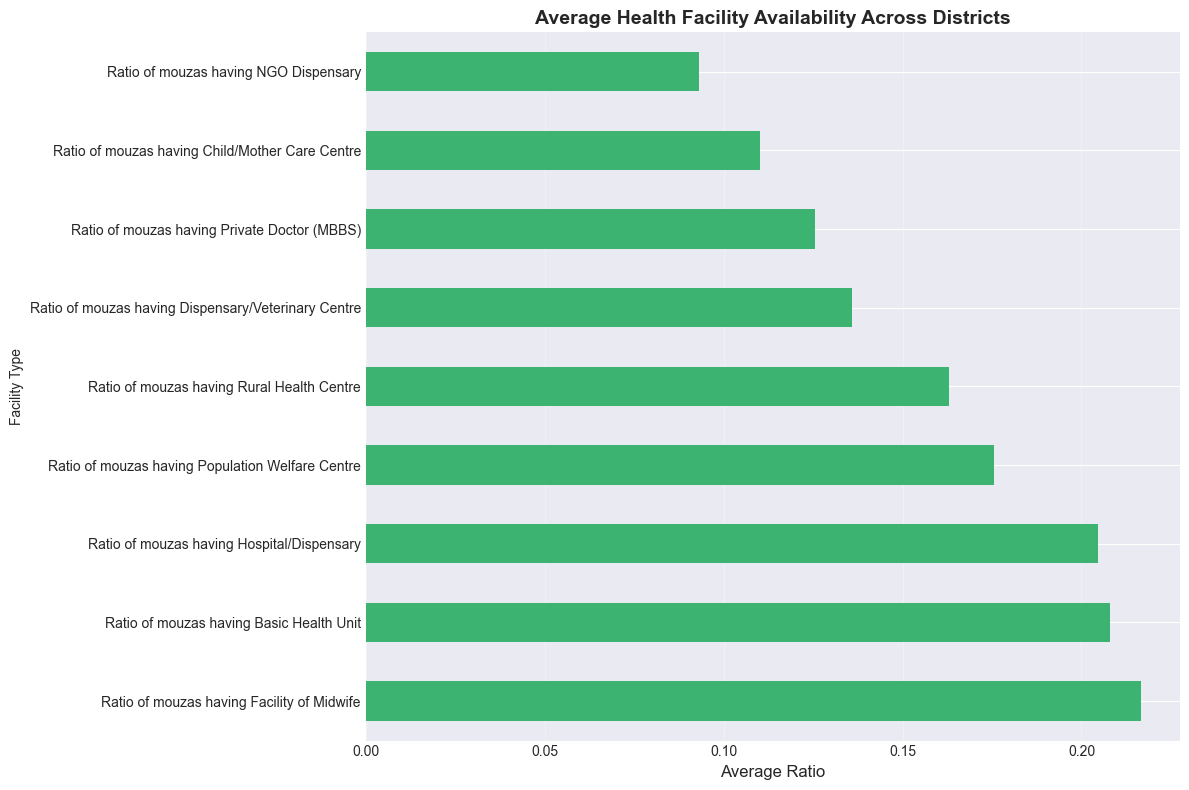


Health Facilities Statistics:
Number of health facility types tracked: 9

Top 5 Most Available:
Ratio of mouzas having Facility of Midwife          0.216705
Ratio of mouzas having Basic Health Unit            0.207848
Ratio of mouzas having Hospital/Dispensary          0.204720
Ratio of mouzas having Population Welfare Centre    0.175443
Ratio of mouzas having Rural Health Centre          0.163013
dtype: float64


In [19]:
# Health facilities availability
health_cols = [col for col in df.columns if 'Ratio of mouzas having' in col and 
               any(x in col for x in ['Health', 'Hospital', 'Dispensary', 'Doctor', 'Midwife', 'Mother', 'Population'])]

avg_health = df[health_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
avg_health.plot(kind='barh', color='mediumseagreen')
plt.title('Average Health Facility Availability Across Districts', fontsize=14, fontweight='bold')
plt.xlabel('Average Ratio', fontsize=12)
plt.ylabel('Facility Type', fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nHealth Facilities Statistics:")
print(f"Number of health facility types tracked: {len(health_cols)}")
print("\nTop 5 Most Available:")
print(avg_health.head())

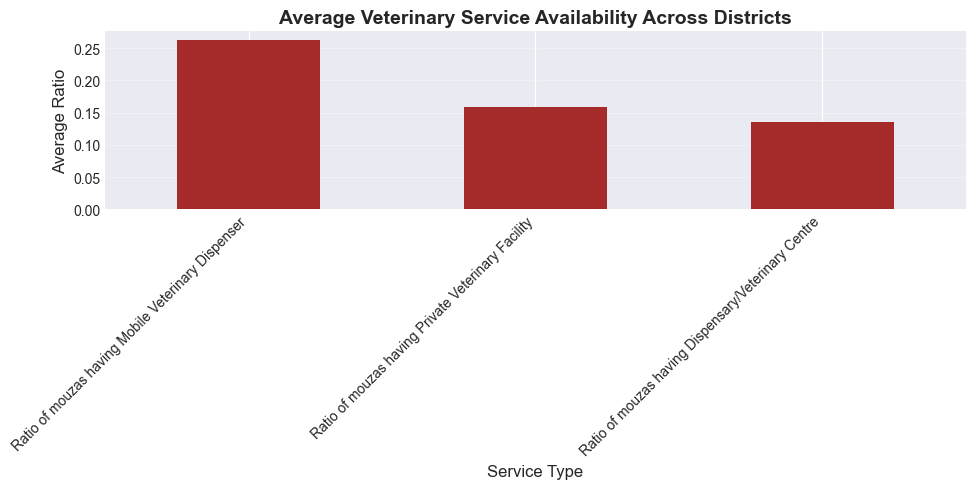


Veterinary Services Statistics:
       Ratio of mouzas having Dispensary/Veterinary Centre  \
count                                         151.000000     
mean                                            0.135986     
std                                             0.104081     
min                                             0.000000     
25%                                             0.066824     
50%                                             0.117788     
75%                                             0.171091     
max                                             0.647059     

       Ratio of mouzas having Private Veterinary Facility  \
count                                         151.000000    
mean                                            0.158329    
std                                             0.114772    
min                                             0.000000    
25%                                             0.062566    
50%                                       

In [20]:
# Veterinary services
vet_cols = ['Ratio of mouzas having Dispensary/Veterinary Centre',
            'Ratio of mouzas having Private Veterinary Facility',
            'Ratio of mouzas having Mobile Veterinary Dispenser']

avg_vet = df[vet_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_vet.plot(kind='bar', color='brown')
plt.title('Average Veterinary Service Availability Across Districts', fontsize=14, fontweight='bold')
plt.xlabel('Service Type', fontsize=12)
plt.ylabel('Average Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVeterinary Services Statistics:")
print(df[vet_cols].describe())

## 9. Market and Economic Facilities

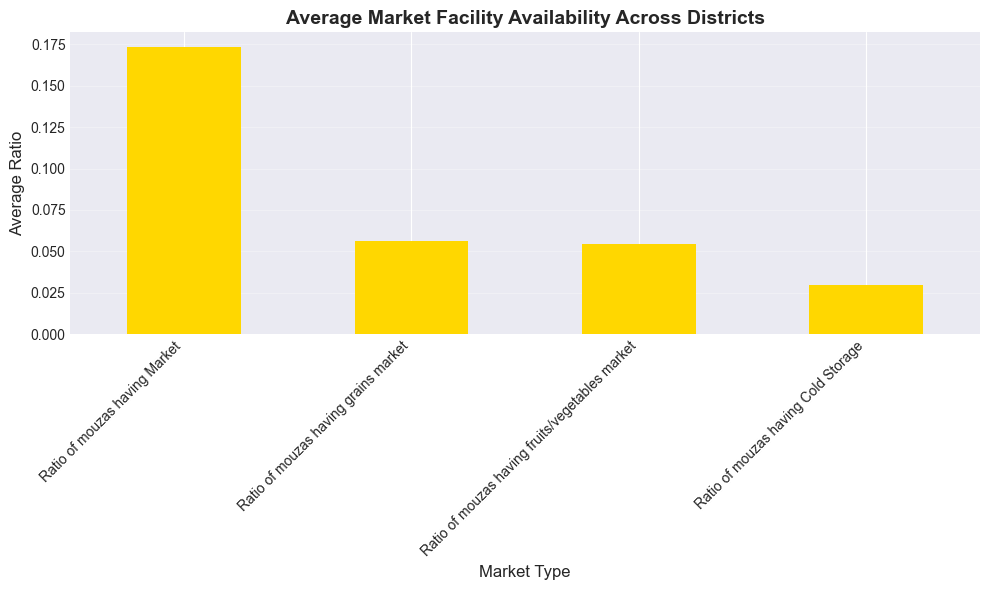


Market Facilities Statistics:
       Ratio of mouzas having Market  Ratio of mouzas having grains market  \
count                     151.000000                            151.000000   
mean                        0.173413                              0.056226   
std                         0.142201                              0.057331   
min                         0.005181                              0.000000   
25%                         0.080660                              0.021105   
50%                         0.124294                              0.038298   
75%                         0.236264                              0.065331   
max                         0.688525                              0.327684   

       Ratio of mouzas having fruits/vegetables market  \
count                                       151.000000   
mean                                          0.054235   
std                                           0.055310   
min                               

In [21]:
# Market facilities
market_cols = ['Ratio of mouzas having Market',
               'Ratio of mouzas having grains market',
               'Ratio of mouzas having fruits/vegetables market',
               'Ratio of mouzas having Cold Storage']

avg_market = df[market_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_market.plot(kind='bar', color='gold')
plt.title('Average Market Facility Availability Across Districts', fontsize=14, fontweight='bold')
plt.xlabel('Market Type', fontsize=12)
plt.ylabel('Average Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMarket Facilities Statistics:")
print(df[market_cols].describe())

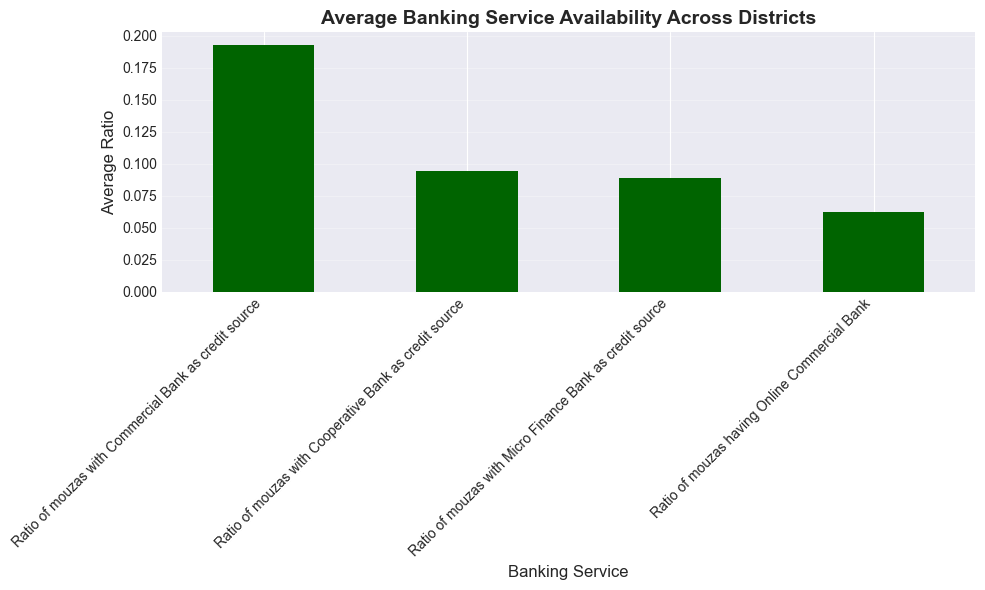


Banking Services Statistics:
       Ratio of mouzas having Online Commercial Bank  \
count                                     151.000000   
mean                                        0.062174   
std                                         0.060739   
min                                         0.000000   
25%                                         0.022277   
50%                                         0.044186   
75%                                         0.075831   
max                                         0.323529   

       Ratio of mouzas with Commercial Bank as credit source  \
count                                         151.000000       
mean                                            0.193053       
std                                             0.216787       
min                                             0.000000       
25%                                             0.014165       
50%                                             0.100604       
75%              

In [22]:
# Banking and credit sources
bank_cols = ['Ratio of mouzas having Online Commercial Bank',
             'Ratio of mouzas with Commercial Bank as credit source',
             'Ratio of mouzas with Cooperative Bank as credit source',
             'Ratio of mouzas with Micro Finance Bank as credit source']

avg_bank = df[bank_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_bank.plot(kind='bar', color='darkgreen')
plt.title('Average Banking Service Availability Across Districts', fontsize=14, fontweight='bold')
plt.xlabel('Banking Service', fontsize=12)
plt.ylabel('Average Ratio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBanking Services Statistics:")
print(df[bank_cols].describe())

## 10. Correlation Analysis

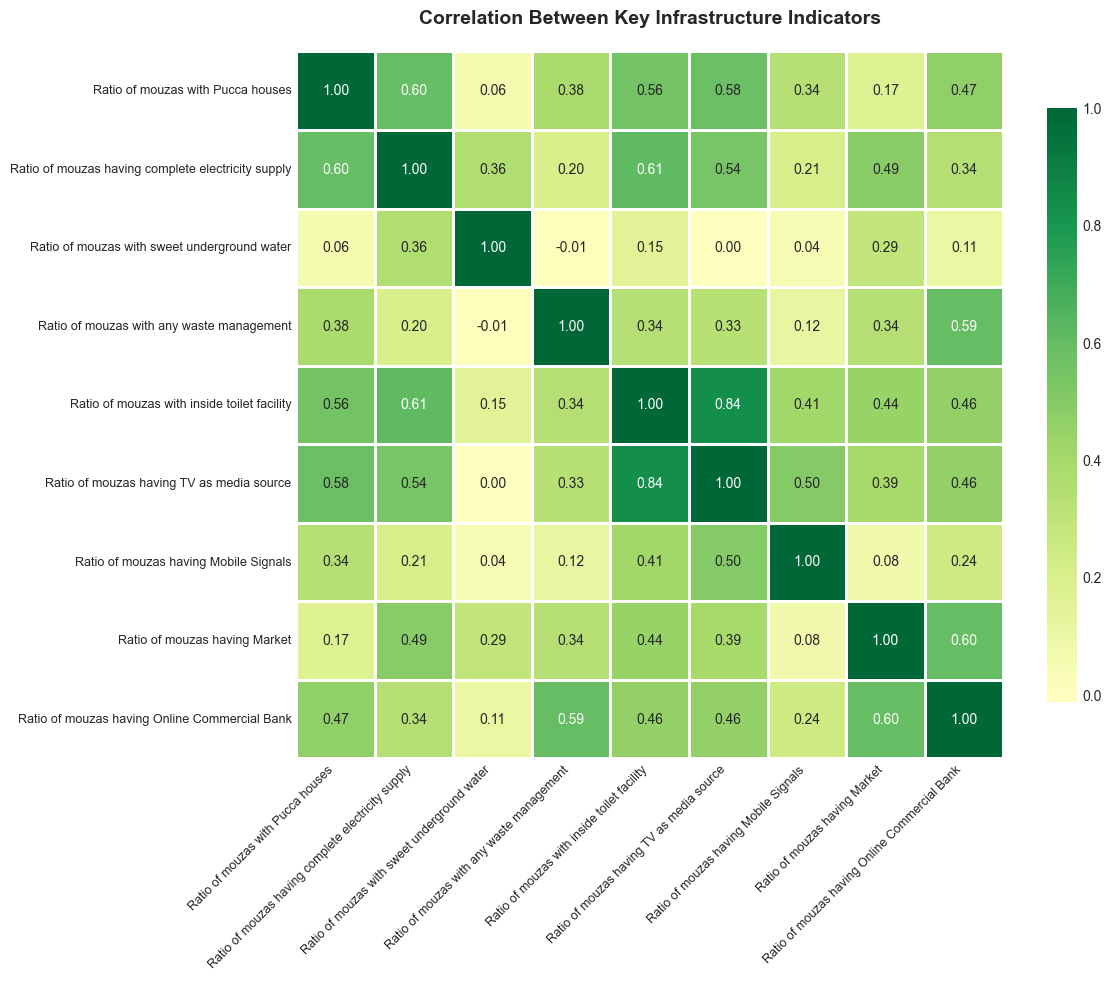

In [23]:
# Select key infrastructure indicators for correlation
key_indicators = [
    'Ratio of mouzas with Pucca houses',
    'Ratio of mouzas having complete electricity supply',
    'Ratio of mouzas with sweet underground water',
    'Ratio of mouzas with any waste management',
    'Ratio of mouzas with inside toilet facility',
    'Ratio of mouzas having TV as media source',
    'Ratio of mouzas having Mobile Signals',
    'Ratio of mouzas having Market',
    'Ratio of mouzas having Online Commercial Bank'
]

# Correlation matrix
corr_matrix = df[key_indicators].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Between Key Infrastructure Indicators', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# Find strongest correlations
# Get upper triangle of correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_no_diag = corr_matrix.mask(mask)

# Get correlations as series and sort
correlations = corr_no_diag.stack().sort_values(ascending=False)

print("\nTop 10 Strongest Positive Correlations:")
print(correlations.head(10))
print("\nTop 10 Strongest Negative Correlations:")
print(correlations.tail(10))


Top 10 Strongest Positive Correlations:
Ratio of mouzas having TV as media source           Ratio of mouzas with inside toilet facility           0.837099
Ratio of mouzas with inside toilet facility         Ratio of mouzas having complete electricity supply    0.609347
Ratio of mouzas having complete electricity supply  Ratio of mouzas with Pucca houses                     0.600678
Ratio of mouzas having Online Commercial Bank       Ratio of mouzas having Market                         0.599606
                                                    Ratio of mouzas with any waste management             0.594497
Ratio of mouzas having TV as media source           Ratio of mouzas with Pucca houses                     0.578712
Ratio of mouzas with inside toilet facility         Ratio of mouzas with Pucca houses                     0.559966
Ratio of mouzas having TV as media source           Ratio of mouzas having complete electricity supply    0.541112
Ratio of mouzas having Mobile Signals  

## 11. Province-wise Comparison

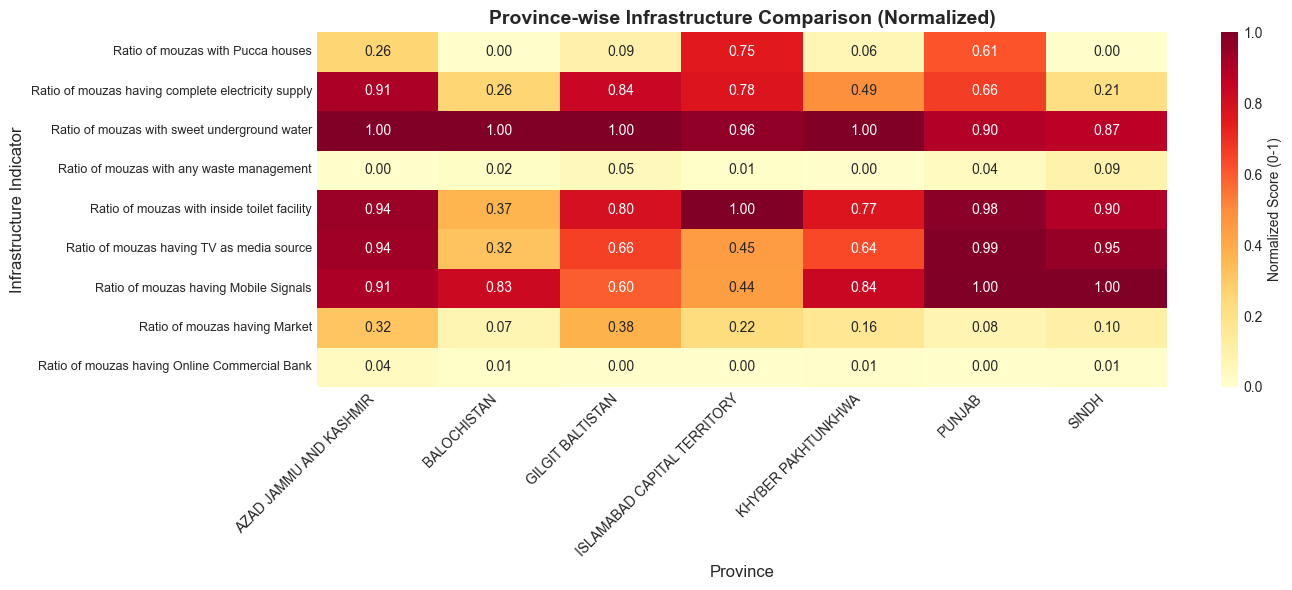


Province-wise Average Infrastructure Scores:
                             Ratio of mouzas with Pucca houses  \
Name of Province                                                 
AZAD JAMMU AND KASHMIR                                0.305186   
BALOCHISTAN                                           0.019293   
GILGIT BALTISTAN                                      0.135366   
ISLAMABAD CAPITAL TERRITORY                           0.805556   
KHYBER PAKHTUNKHWA                                    0.120440   
PUNJAB                                                0.578791   
SINDH                                                 0.059438   

                             Ratio of mouzas having complete electricity supply  \
Name of Province                                                                  
AZAD JAMMU AND KASHMIR                                                0.911878    
BALOCHISTAN                                                           0.226123    
GILGIT BALTISTAN           

In [25]:
# Create a comprehensive comparison across provinces
province_comparison = df.groupby('Name of Province')[key_indicators].mean()

# Normalize for radar chart
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
province_normalized = pd.DataFrame(
    scaler.fit_transform(province_comparison.T).T,
    index=province_comparison.index,
    columns=province_comparison.columns
)

# Heatmap comparison
plt.figure(figsize=(14, 6))
sns.heatmap(province_normalized.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Normalized Score (0-1)'})
plt.title('Province-wise Infrastructure Comparison (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Infrastructure Indicator', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("\nProvince-wise Average Infrastructure Scores:")
print(province_comparison)

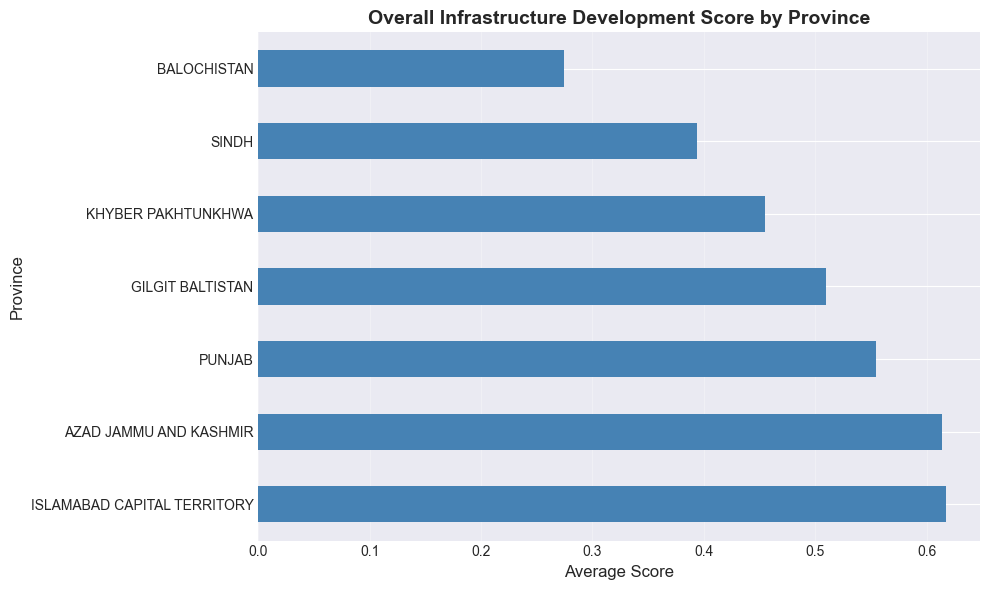


Overall Development Scores by Province:
Name of Province
ISLAMABAD CAPITAL TERRITORY    0.617141
AZAD JAMMU AND KASHMIR         0.614251
PUNJAB                         0.554619
GILGIT BALTISTAN               0.509756
KHYBER PAKHTUNKHWA             0.454786
SINDH                          0.394294
BALOCHISTAN                    0.274406
Name: Overall_Score, dtype: float64


In [26]:
# Overall development score by province
province_comparison['Overall_Score'] = province_comparison.mean(axis=1)
province_comparison = province_comparison.sort_values('Overall_Score', ascending=False)

plt.figure(figsize=(10, 6))
province_comparison['Overall_Score'].plot(kind='barh', color='steelblue')
plt.title('Overall Infrastructure Development Score by Province', fontsize=14, fontweight='bold')
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Province', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOverall Development Scores by Province:")
print(province_comparison['Overall_Score'])

## 12. District Rankings

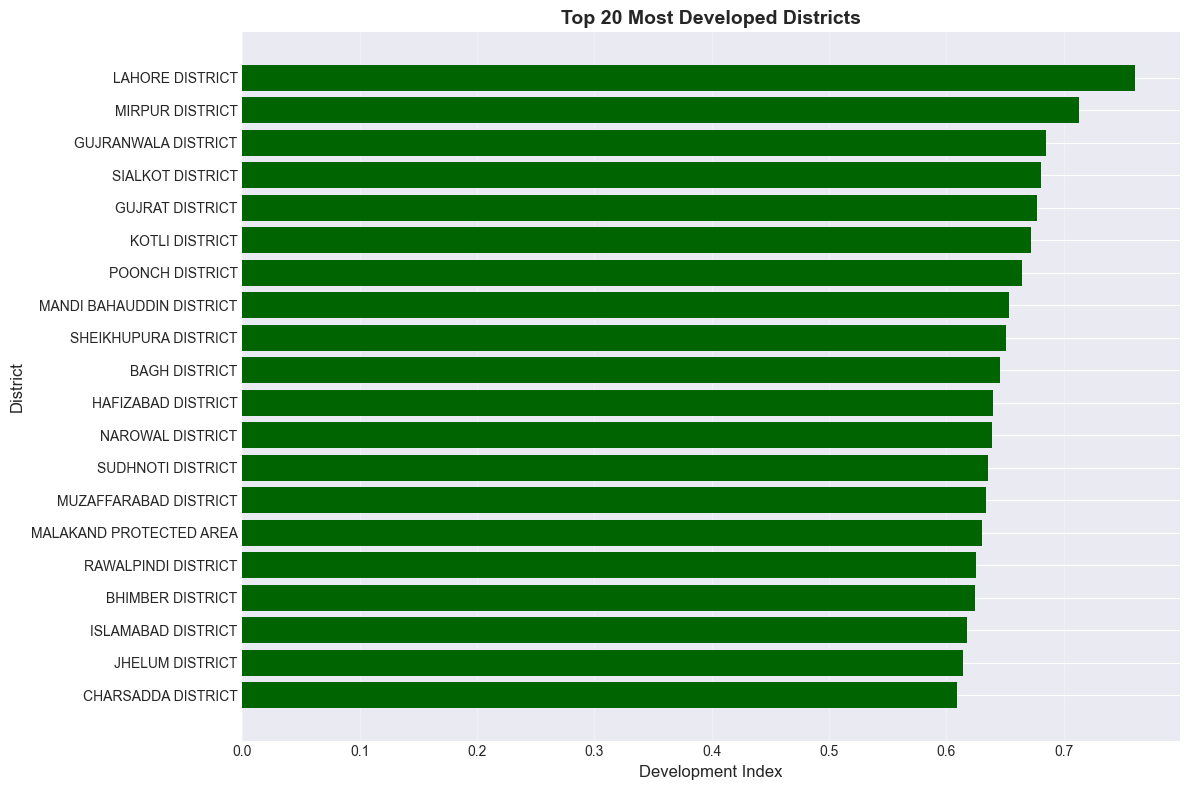


Top 20 Most Developed Districts:
        Name of District            Name of Province  Development_Index
         LAHORE DISTRICT                      PUNJAB           0.761000
         MIRPUR DISTRICT      AZAD JAMMU AND KASHMIR           0.713352
     GUJRANWALA DISTRICT                      PUNJAB           0.684683
        SIALKOT DISTRICT                      PUNJAB           0.680825
         GUJRAT DISTRICT                      PUNJAB           0.676844
          KOTLI DISTRICT      AZAD JAMMU AND KASHMIR           0.671890
         POONCH DISTRICT      AZAD JAMMU AND KASHMIR           0.664216
MANDI BAHAUDDIN DISTRICT                      PUNJAB           0.653067
    SHEIKHUPURA DISTRICT                      PUNJAB           0.650349
           BAGH DISTRICT      AZAD JAMMU AND KASHMIR           0.646032
      HAFIZABAD DISTRICT                      PUNJAB           0.639923
        NAROWAL DISTRICT                      PUNJAB           0.639246
       SUDHNOTI DISTRICT      

In [27]:
# Create overall development index for each district
df['Development_Index'] = df[key_indicators].mean(axis=1)

# Top 20 most developed districts
top_20 = df.nlargest(20, 'Development_Index')[['Name of District', 'Name of Province', 'Development_Index']]

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_20)), top_20['Development_Index'], color='darkgreen')
plt.yticks(range(len(top_20)), top_20['Name of District'])
plt.xlabel('Development Index', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.title('Top 20 Most Developed Districts', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 20 Most Developed Districts:")
print(top_20.to_string(index=False))

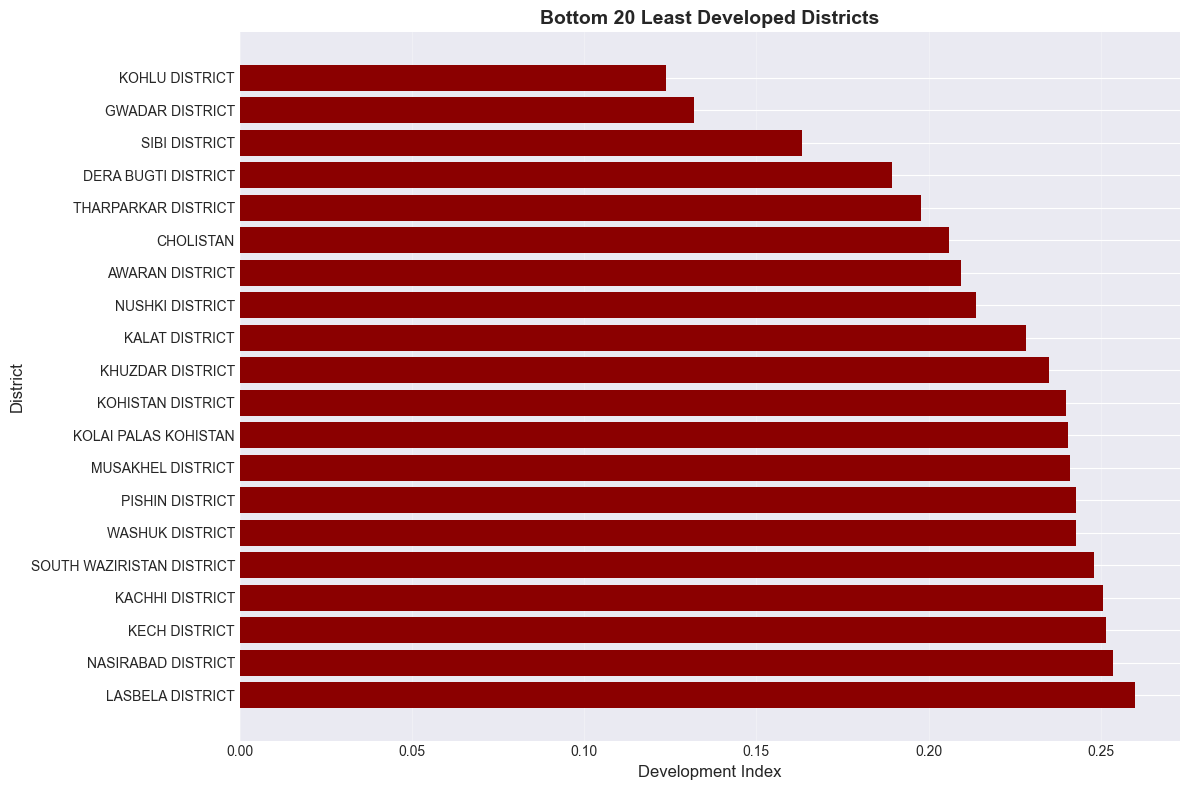


Bottom 20 Least Developed Districts:
         Name of District   Name of Province  Development_Index
           KOHLU DISTRICT        BALOCHISTAN           0.123777
          GWADAR DISTRICT        BALOCHISTAN           0.131790
            SIBI DISTRICT        BALOCHISTAN           0.163300
      DERA BUGTI DISTRICT        BALOCHISTAN           0.189484
      THARPARKAR DISTRICT              SINDH           0.197674
                CHOLISTAN             PUNJAB           0.205918
          AWARAN DISTRICT        BALOCHISTAN           0.209443
          NUSHKI DISTRICT        BALOCHISTAN           0.213889
           KALAT DISTRICT        BALOCHISTAN           0.228254
         KHUZDAR DISTRICT        BALOCHISTAN           0.235052
        KOHISTAN DISTRICT KHYBER PAKHTUNKHWA           0.240044
     KOLAI PALAS KOHISTAN KHYBER PAKHTUNKHWA           0.240532
        MUSAKHEL DISTRICT        BALOCHISTAN           0.241002
          PISHIN DISTRICT        BALOCHISTAN           0.242810
  

In [28]:
# Bottom 20 least developed districts
bottom_20 = df.nsmallest(20, 'Development_Index')[['Name of District', 'Name of Province', 'Development_Index']]

plt.figure(figsize=(12, 8))
plt.barh(range(len(bottom_20)), bottom_20['Development_Index'], color='darkred')
plt.yticks(range(len(bottom_20)), bottom_20['Name of District'])
plt.xlabel('Development Index', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.title('Bottom 20 Least Developed Districts', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nBottom 20 Least Developed Districts:")
print(bottom_20.to_string(index=False))

## 13. Key Insights and Summary

In [29]:
# Summary statistics
print("="*80)
print("MOUZA CENSUS 2020 - KEY INSIGHTS SUMMARY")
print("="*80)

print("\n1. GEOGRAPHIC COVERAGE:")
print(f"   - Total Districts: {len(df)}")
print(f"   - Provinces: {df['Name of Province'].nunique()}")
print(f"   - Divisions: {df['Name of Division'].nunique()}")
print(f"   - Total Settlements Covered: {df['Total Number of Settlements'].sum():,.0f}")
print(f"   - Total Villages: {df['Total Villages'].sum():,.0f}")

print("\n2. HOUSING QUALITY:")
print(f"   - Average Pucca Houses: {df['Ratio of mouzas with Pucca houses'].mean():.2%}")
print(f"   - Average Kutcha Houses: {df['Ratio of mouzas with Kutcha houses'].mean():.2%}")
print(f"   - Districts with >80% Pucca: {(df['Ratio of mouzas with Pucca houses'] > 0.8).sum()}")

print("\n3. ELECTRICITY ACCESS:")
print(f"   - Complete Coverage: {df['Ratio of mouzas having complete electricity supply'].mean():.2%}")
print(f"   - No Electricity: {df['Ratio of mouzas having no electricity supply'].mean():.2%}")
print(f"   - Districts with >90% Coverage: {(df['Total_Electricity_Access'] > 0.9).sum()}")

print("\n4. WATER ACCESS:")
print(f"   - Sweet Underground Water: {df['Ratio of mouzas with sweet underground water'].mean():.2%}")
print(f"   - Avg Water Table Depth: {df['Average Depth of Water Table (ft)'].mean():.0f} feet")
print(f"   - Govt Piped Supply: {df['Ratio of mouzas with govt piped supply for drinking water'].mean():.2%}")

print("\n5. SANITATION:")
print(f"   - Inside Toilet Facility: {df['Ratio of mouzas with inside toilet facility'].mean():.2%}")
print(f"   - Any Waste Management: {df['Ratio of mouzas with any waste management'].mean():.2%}")
print(f"   - Complete Sewerage: {df['Ratio of mouzas with complete sewerage system coverage'].mean():.2%}")

print("\n6. CONNECTIVITY:")
print(f"   - Mobile Signals: {df['Ratio of mouzas having Mobile Signals'].mean():.2%}")
print(f"   - TV Access: {df['Ratio of mouzas having TV as media source'].mean():.2%}")
print(f"   - Mobile Internet: {df['Ratio of mouzas with mobile net'].mean():.2%}")

print("\n7. DEVELOPMENT DISPARITY:")
print(f"   - Most Developed District: {df.nlargest(1, 'Development_Index')['Name of District'].values[0]}")
print(f"   - Development Score: {df['Development_Index'].max():.3f}")
print(f"   - Least Developed District: {df.nsmallest(1, 'Development_Index')['Name of District'].values[0]}")
print(f"   - Development Score: {df['Development_Index'].min():.3f}")
print(f"   - Development Gap: {(df['Development_Index'].max() - df['Development_Index'].min()):.3f}")

print("\n" + "="*80)

MOUZA CENSUS 2020 - KEY INSIGHTS SUMMARY

1. GEOGRAPHIC COVERAGE:
   - Total Districts: 151
   - Provinces: 7
   - Divisions: 37
   - Total Settlements Covered: 170,347
   - Total Villages: 51,030

2. HOUSING QUALITY:
   - Average Pucca Houses: 21.83%
   - Average Kutcha Houses: 31.17%
   - Districts with >80% Pucca: 12

3. ELECTRICITY ACCESS:
   - Complete Coverage: 47.45%
   - No Electricity: 16.91%
   - Districts with >90% Coverage: 55

4. WATER ACCESS:
   - Sweet Underground Water: 85.10%
   - Avg Water Table Depth: 205 feet
   - Govt Piped Supply: 19.41%

5. SANITATION:
   - Inside Toilet Facility: 69.71%
   - Any Waste Management: 7.97%
   - Complete Sewerage: 1.49%

6. CONNECTIVITY:
   - Mobile Signals: 79.00%
   - TV Access: 65.96%
   - Mobile Internet: 71.62%

7. DEVELOPMENT DISPARITY:
   - Most Developed District: LAHORE DISTRICT
   - Development Score: 0.761
   - Least Developed District: KOHLU DISTRICT
   - Development Score: 0.124
   - Development Gap: 0.637



## 14. Export Analysis Results

In [30]:
# Create summary dataframe for export
summary_df = df[['Name of District', 'Name of Province', 'Name of Division', 
                  'Total Number of Settlements', 'Total Villages', 'Development_Index']].copy()

# Add key infrastructure scores
summary_df['Housing_Score'] = df[['Ratio of mouzas with Pucca houses']].mean(axis=1)
summary_df['Electricity_Score'] = df['Total_Electricity_Access']
summary_df['Water_Score'] = df['Ratio of mouzas with sweet underground water']
summary_df['Sanitation_Score'] = df[['Ratio of mouzas with inside toilet facility', 
                                       'Ratio of mouzas with any waste management']].mean(axis=1)
summary_df['Connectivity_Score'] = df[['Ratio of mouzas having Mobile Signals', 
                                        'Ratio of mouzas having TV as media source']].mean(axis=1)

# Sort by development index
summary_df = summary_df.sort_values('Development_Index', ascending=False)

# Save to CSV
summary_df.to_csv('district_development_summary.csv', index=False)
print("Summary exported to 'district_development_summary.csv'")

# Display top 10
print("\nTop 10 Districts by Development Index:")
print(summary_df.head(10).to_string(index=False))

Summary exported to 'district_development_summary.csv'

Top 10 Districts by Development Index:
        Name of District       Name of Province    Name of Division  Total Number of Settlements  Total Villages  Development_Index  Housing_Score  Electricity_Score  Water_Score  Sanitation_Score  Connectivity_Score
         LAHORE DISTRICT                 PUNJAB     LAHORE DIVISION                          873             363           0.761000       0.914530           0.982906     0.877493          0.814815            0.914530
         MIRPUR DISTRICT AZAD JAMMU AND KASHMIR     MIRPUR DIVISION                          897             244           0.713352       0.781513           0.987395     0.995798          0.558824            0.985294
     GUJRANWALA DISTRICT                 PUNJAB GUJRANWALA DIVISION                         1387             813           0.684683       0.931119           0.997540     0.945879          0.595941            0.952070
        SIALKOT DISTRICT             

---

## Conclusion

This exploratory analysis reveals significant variations in infrastructure and services across Pakistan's districts. The ratio-based metrics effectively capture the breadth of service availability within each district, highlighting areas of strength and opportunities for development.

### Key Takeaways:
1. **Urban-Rural Divide**: Pucca house ratios serve as a proxy for urbanization levels
2. **Infrastructure Correlation**: Basic utilities (electricity, water) strongly correlate with other development indicators
3. **Provincial Patterns**: Distinct development patterns emerge across provinces
4. **Service Gaps**: Significant gaps exist in sanitation, waste management, and advanced connectivity
5. **Health & Education**: Facility availability varies widely, with distance metrics revealing accessibility challenges

### Recommendations for Further Analysis:
- **Clustering Analysis**: Group districts by development profiles
- **Time Series**: If historical data available, track progress over time
- **Predictive Modeling**: Identify factors most strongly associated with development
- **Geographic Visualization**: Map-based analysis to identify spatial patterns
- **Policy Impact**: Analyze effectiveness of targeted interventions in specific districts